# Unsupervised SPI–SPI macrostate coordinate — leakage-controlled pilot

This notebook asks one narrow question: **can a scalar coordinate learned from SPI–SPI meta-features without using $\alpha$ be applied inductively to unseen initial conditions and unseen, interleaved $\alpha$ values?**

It deliberately does not call $\alpha$ an order parameter. The physical interpretation is reserved for independent diagnostics and a later confirmatory campaign.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.manifold import Isomap

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "features").exists():
    ROOT = ROOT.parent
FEATURES = ROOT / "features/data-embeddings-cml_param_sweep_260508_pearson.npz"
assert FEATURES.exists(), FEATURES
print(ROOT)

/Users/wedi0306/Code/mts-spi-study-cluster


## Frozen discovery/confirmation-like split

The representation is fitted only on instances 0–9 at alternating grid values. Evaluation uses instances 10–19 at the interleaved, unseen grid values. Feature filtering, PCA and Isomap are all fitted on discovery data only. $\alpha$ is used afterwards for orientation and evaluation, never as a learning target.

In [2]:
data = dict(np.load(FEATURES, allow_pickle=True))
alpha = np.array([float(v[1:].replace("p", ".")) for v in data["variant"]])
instance = data["instance"].astype(int)
alpha_grid = np.unique(alpha)
grid_index = np.searchsorted(alpha_grid, alpha)

discovery = (grid_index % 2 == 0) & (instance < 10)
confirmation = (grid_index % 2 == 1) & (instance >= 10)

X0 = data["X"].astype(np.float64)
keep = X0[discovery].std(axis=0) >= 0.05
X = X0[:, keep]

pca = PCA(n_components=10, random_state=0).fit(X[discovery])
P_discovery = pca.transform(X[discovery])
P_confirmation = pca.transform(X[confirmation])

# Nominal, label-free manifold model. Sensitivity to neighbour count is shown below.
isomap = Isomap(n_neighbors=15, n_components=1).fit(P_discovery)
q_discovery = isomap.embedding_[:, 0]
q_confirmation = isomap.transform(P_confirmation)[:, 0]

a_discovery = alpha[discovery]
a_confirmation = alpha[confirmation]
orientation = np.sign(spearmanr(a_discovery, q_discovery).statistic) or 1.0
q_discovery *= orientation
q_confirmation *= orientation

print(f"discovery: {discovery.sum()} samples, {np.unique(a_discovery).size} alpha values")
print(f"confirmation-like: {confirmation.sum()} samples, {np.unique(a_confirmation).size} unseen alpha values")
print(f"features retained from discovery only: {keep.sum():,}/{keep.size:,}")
print(f"PCA-10 cumulative variance: {pca.explained_variance_ratio_.sum():.3f}")

discovery: 210 samples, 21 alpha values
confirmation-like: 200 samples, 20 unseen alpha values
features retained from discovery only: 37,109/39,567
PCA-10 cumulative variance: 0.903


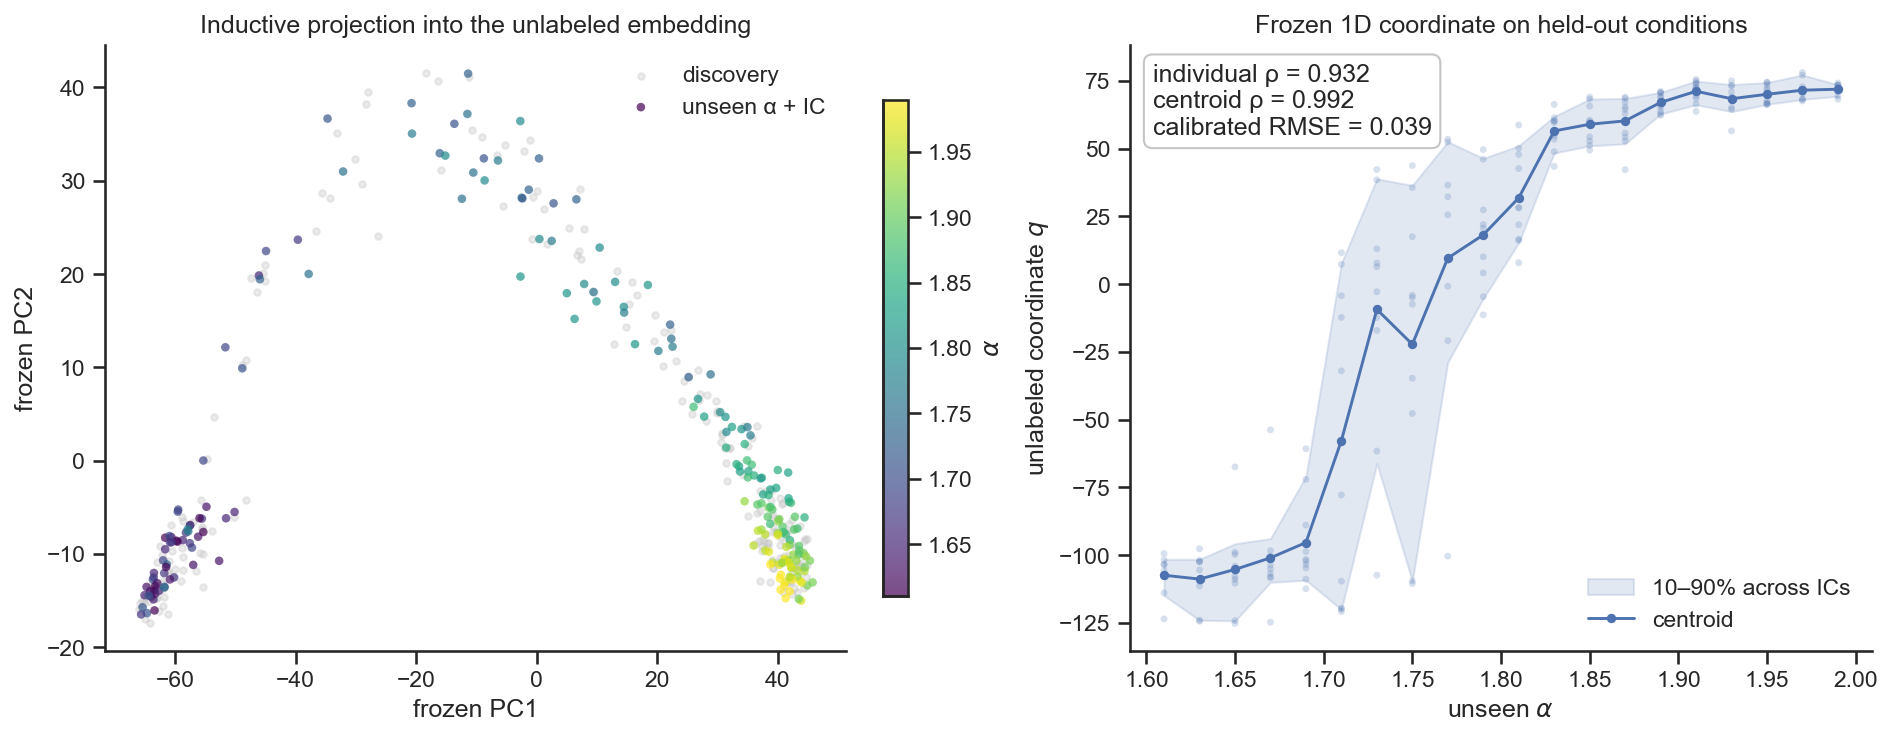

In [3]:
def centroid_curve(a, q):
    grid = np.unique(a)
    centre = np.array([np.mean(q[a == x]) for x in grid])
    lo = np.array([np.quantile(q[a == x], 0.10) for x in grid])
    hi = np.array([np.quantile(q[a == x], 0.90) for x in grid])
    return grid, centre, lo, hi

a_test_grid, q_centre, q_lo, q_hi = centroid_curve(a_confirmation, q_confirmation)
rho_individual = spearmanr(a_confirmation, q_confirmation).statistic
rho_centroid = spearmanr(a_test_grid, q_centre).statistic

calibrator = IsotonicRegression(out_of_bounds="clip").fit(q_discovery, a_discovery)
alpha_hat = calibrator.predict(q_confirmation)
rmse = np.sqrt(np.mean((alpha_hat - a_confirmation) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
ax = axes[0]
ax.scatter(P_discovery[:, 0], P_discovery[:, 1], s=10, color="0.78", alpha=0.35, label="discovery")
sc = ax.scatter(P_confirmation[:, 0], P_confirmation[:, 1], c=a_confirmation, cmap="viridis", s=17, alpha=0.70, edgecolor="none", label="unseen α + IC")
fig.colorbar(sc, ax=ax, label=r"$\alpha$", shrink=0.82)
ax.set(xlabel="frozen PC1", ylabel="frozen PC2", title="Inductive projection into the unlabeled embedding")
ax.legend(frameon=False, loc="best")

ax = axes[1]
ax.scatter(a_confirmation, q_confirmation, s=11, alpha=0.22, color="C0", edgecolor="none")
ax.fill_between(a_test_grid, q_lo, q_hi, color="C0", alpha=0.16, label="10–90% across ICs")
ax.plot(a_test_grid, q_centre, "-o", ms=3.5, lw=1.4, color="C0", label="centroid")
ax.set(xlabel=r"unseen $\alpha$", ylabel=r"unlabeled coordinate $q$", title="Frozen 1D coordinate on held-out conditions")
ax.text(0.03, 0.97, f"individual ρ = {rho_individual:.3f}\ncentroid ρ = {rho_centroid:.3f}\ncalibrated RMSE = {rmse:.3f}", transform=ax.transAxes, va="top", bbox=dict(boxstyle="round,pad=.35", fc="white", ec="0.75", alpha=.9))
ax.legend(frameon=False, loc="lower right")
sns.despine(fig)
plt.show()

## Strongest simple baselines

A successful meta-feature need not be unique, but a physical-discovery claim is weak if elementary raw summaries reproduce it. Each scalar below is computed directly from the retained field and receives the same post-hoc monotone calibration as $q$.

In [4]:
selected = discovery | confirmation
raw = {name: np.full(len(alpha), np.nan) for name in ["mean", "std", "mean |x|", "spatial variance", "neighbour corr.", "lag-1 corr."]}
for i in np.where(selected)[0]:
    Y = np.load(ROOT / str(data["dataset_paths"][i]) / "timeseries.npy").astype(float)
    raw["mean"][i] = Y.mean()
    raw["std"][i] = Y.std()
    raw["mean |x|"][i] = np.abs(Y).mean()
    raw["spatial variance"][i] = Y.var(axis=1).mean()
    raw["neighbour corr."][i] = np.corrcoef(Y[:, :-1].ravel(), Y[:, 1:].ravel())[0, 1]
    raw["lag-1 corr."][i] = np.corrcoef(Y[:-1].ravel(), Y[1:].ravel())[0, 1]

def evaluate_coordinate(name, train_values, test_values):
    sign = np.sign(spearmanr(a_discovery, train_values).statistic) or 1.0
    train_values = sign * np.asarray(train_values)
    test_values = sign * np.asarray(test_values)
    test_grid, test_centre, _, _ = centroid_curve(a_confirmation, test_values)
    fit = IsotonicRegression(out_of_bounds="clip").fit(train_values, a_discovery)
    prediction = fit.predict(test_values)
    return {
        "coordinate": name,
        "individual |rho|": abs(spearmanr(a_confirmation, test_values).statistic),
        "centroid |rho|": abs(spearmanr(test_grid, test_centre).statistic),
        "alpha RMSE": np.sqrt(np.mean((prediction - a_confirmation) ** 2)),
    }

rows = [evaluate_coordinate("SPI–SPI Isomap", q_discovery, q_confirmation),
        evaluate_coordinate("SPI–SPI PC1", P_discovery[:, 0], P_confirmation[:, 0])]
for name, values in raw.items():
    rows.append(evaluate_coordinate(name, values[discovery], values[confirmation]))
scores = pd.DataFrame(rows).sort_values("alpha RMSE")
scores.round(3)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/wedi0306/Code/mts-spi-study-cluster/data/embeddings/cml_param_sweep_260508/cml-alpha-sweep/M20_T1000_I0_a1p60/timeseries.npy'

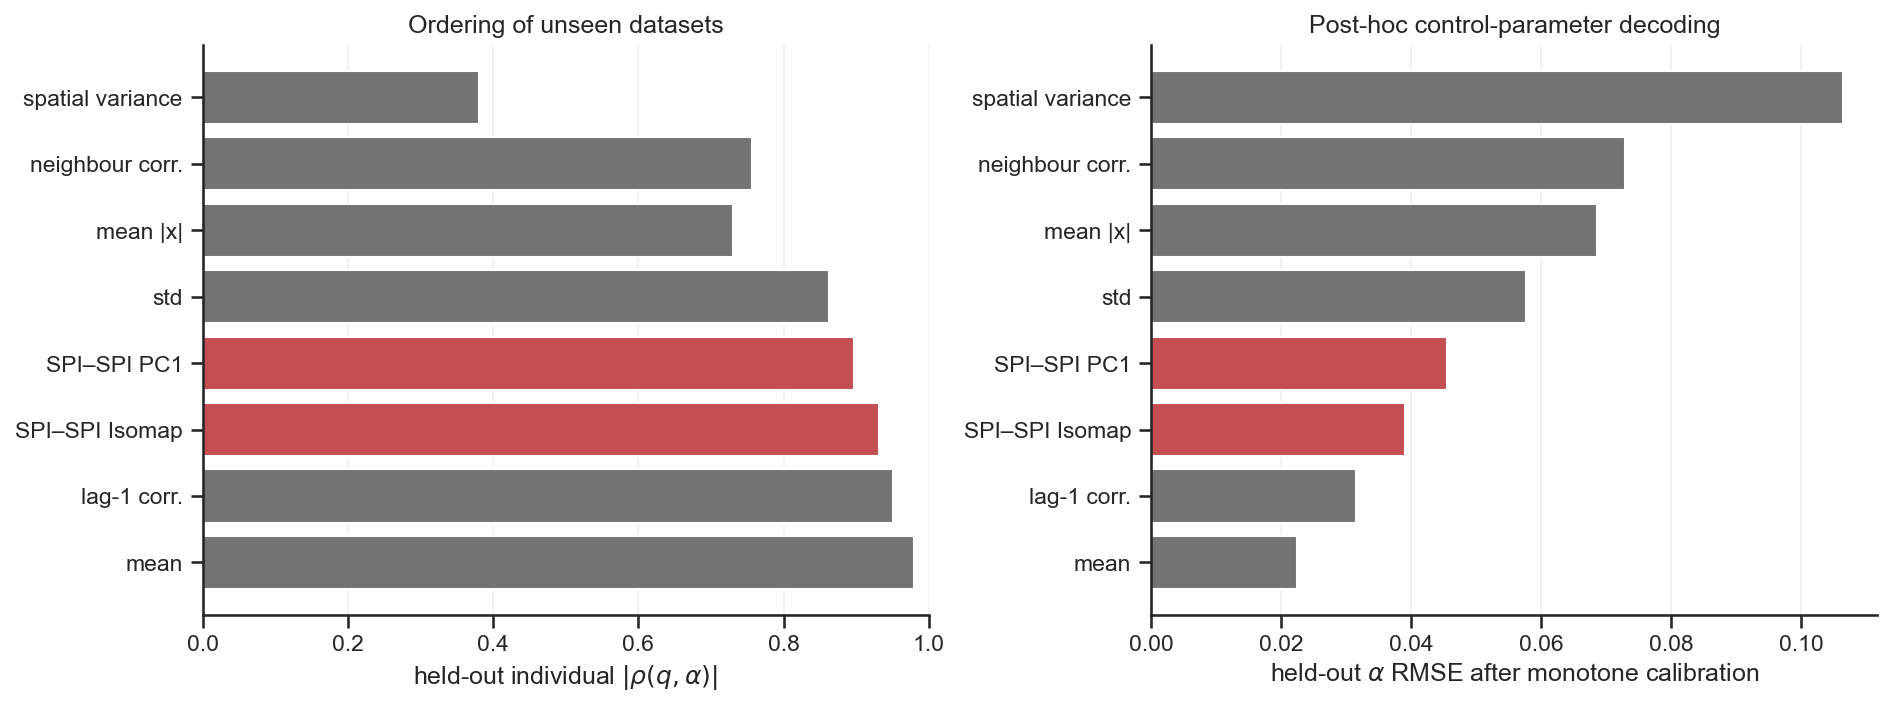

In [ ]:
palette = ["C3" if x.startswith("SPI–SPI") else "0.45" for x in scores["coordinate"]]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)
axes[0].barh(scores["coordinate"], scores["individual |rho|"], color=palette)
axes[0].set(xlim=(0, 1), xlabel=r"held-out individual $|\rho(q,\alpha)|$", title="Ordering of unseen datasets")
axes[1].barh(scores["coordinate"], scores["alpha RMSE"], color=palette)
axes[1].set(xlabel=r"held-out $\alpha$ RMSE after monotone calibration", title="Post-hoc control-parameter decoding")
for ax in axes:
    ax.grid(axis="x", alpha=.25)
sns.despine(fig)
plt.show()

## Coordinate stability and uncertainty

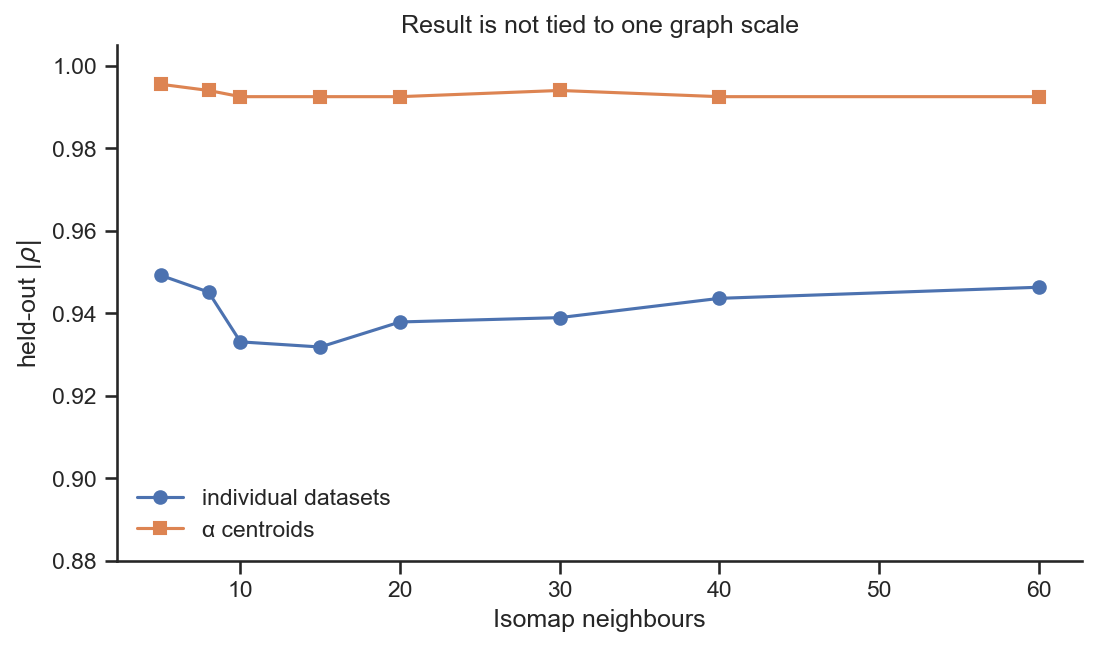

Nominal centroid rho bootstrap 95% interval: [0.968, 0.994]


In [ ]:
neighbours = np.array([5, 8, 10, 15, 20, 30, 40, 60])
rho_sample, rho_mean = [], []
for n_neighbors in neighbours:
    model = Isomap(n_neighbors=int(n_neighbors), n_components=1).fit(P_discovery)
    q0 = model.embedding_[:, 0]
    q1 = model.transform(P_confirmation)[:, 0]
    sign = np.sign(spearmanr(a_discovery, q0).statistic) or 1.0
    q1 *= sign
    grid, centre, _, _ = centroid_curve(a_confirmation, q1)
    rho_sample.append(abs(spearmanr(a_confirmation, q1).statistic))
    rho_mean.append(abs(spearmanr(grid, centre).statistic))

rng = np.random.default_rng(110305)
boot = np.empty(5000)
for b in range(len(boot)):
    means = []
    for a in a_test_grid:
        values = q_confirmation[a_confirmation == a]
        means.append(rng.choice(values, size=len(values), replace=True).mean())
    boot[b] = spearmanr(a_test_grid, means).statistic
ci = np.quantile(boot, [0.025, 0.975])

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.plot(neighbours, rho_sample, "-o", label="individual datasets")
ax.plot(neighbours, rho_mean, "-s", label="α centroids")
ax.set(xlabel="Isomap neighbours", ylabel=r"held-out $|\rho|$", ylim=(0.88, 1.005), title="Result is not tied to one graph scale")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()
print(f"Nominal centroid rho bootstrap 95% interval: [{ci[0]:.3f}, {ci[1]:.3f}]")

## Pilot verdict

**Supported:** without using $\alpha$ during representation learning, a frozen SPI–SPI coordinate orders unseen initial conditions at unseen, interleaved control values. This is a real inductive result, not cumulative arc length or a transductive colour plot.

**Not supported yet:** that the coordinate is a distinctive physical order parameter. Elementary raw statistics equal or outperform it for estimating $\alpha$, and this archive contains only one $\varepsilon$, one observed $M$, one $T$, one crop and a cropped—not full—physical lattice.

A confirmatory study must freeze the unlabeled coordinate, define an SPI-blind physical response, and test transfer across $\varepsilon$, lattice size, observation scale, continuation direction and structure-destroying surrogates.